<a href="https://colab.research.google.com/github/nielitropar/computer-vision/blob/main/mnist_for_beginners.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST Digit Classification — A Beginner's Guide

Welcome! In this notebook, you will build your **very first image classifier** using Python.

By the end, your computer will be able to **look at a handwritten digit and guess what number it is** (0–9).

---

### What is MNIST?

MNIST is a famous dataset of **70,000 handwritten digit images** (28×28 pixels each).
- **60,000 images** are used for *training* (teaching the model)
- **10,000 images** are used for *testing* (checking how well it learned)

It's considered the "Hello World" of machine learning!

---

### Our Plan
1. Install & import libraries
2. Load the data
3. Explore & visualize the data
4. Prepare (preprocess) the data
5. Build a neural network model
6. Train the model
7. Evaluate accuracy
8. Make predictions on new images

>  **Tip:** Run each cell one at a time by pressing **Shift + Enter**.

## Step 1: Install & Import Libraries

We need a few Python libraries:
- **TensorFlow / Keras** — builds and trains neural networks (the brain of our classifier)
- **NumPy** — works with numbers and arrays
- **Matplotlib** — draws charts and images

In [1]:
# Run this cell first to install TensorFlow if it's not already installed
# The exclamation mark (!) lets us run a terminal command from inside a notebook
!pip install tensorflow --quiet

In [2]:
# Import the tools we need
import tensorflow as tf          # The main deep-learning library
import numpy as np               # For working with arrays of numbers
import matplotlib.pyplot as plt  # For drawing plots and images

# This line makes our plots show up inside the notebook
%matplotlib inline

print("Libraries imported successfully!")
print(f"   TensorFlow version: {tf.__version__}")

Libraries imported successfully!
   TensorFlow version: 2.20.0


## Step 2: Load the MNIST Dataset

Keras (part of TensorFlow) has MNIST built in — we can download it with one line!

In [3]:
# Load the dataset
# mnist.load_data() returns two tuples:
#   (x_train, y_train) → 60,000 training images and their labels
#   (x_test,  y_test)  → 10,000 testing  images and their labels

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Dataset loaded! Here's what we have:")
print(f"  Training images : {x_train.shape}  → {x_train.shape[0]} images, each {x_train.shape[1]}x{x_train.shape[2]} pixels")
print(f"  Training labels : {y_train.shape}  → one number (0-9) per image")
print(f"  Testing  images : {x_test.shape}")
print(f"  Testing  labels : {y_test.shape}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded! Here's what we have:
  Training images : (60000, 28, 28)  → 60000 images, each 28x28 pixels
  Training labels : (60000,)  → one number (0-9) per image
  Testing  images : (10000, 28, 28)
  Testing  labels : (10000,)


## Step 3: Explore & Visualize the Data

Before building anything, let's **look at the data** to understand what we're working with.

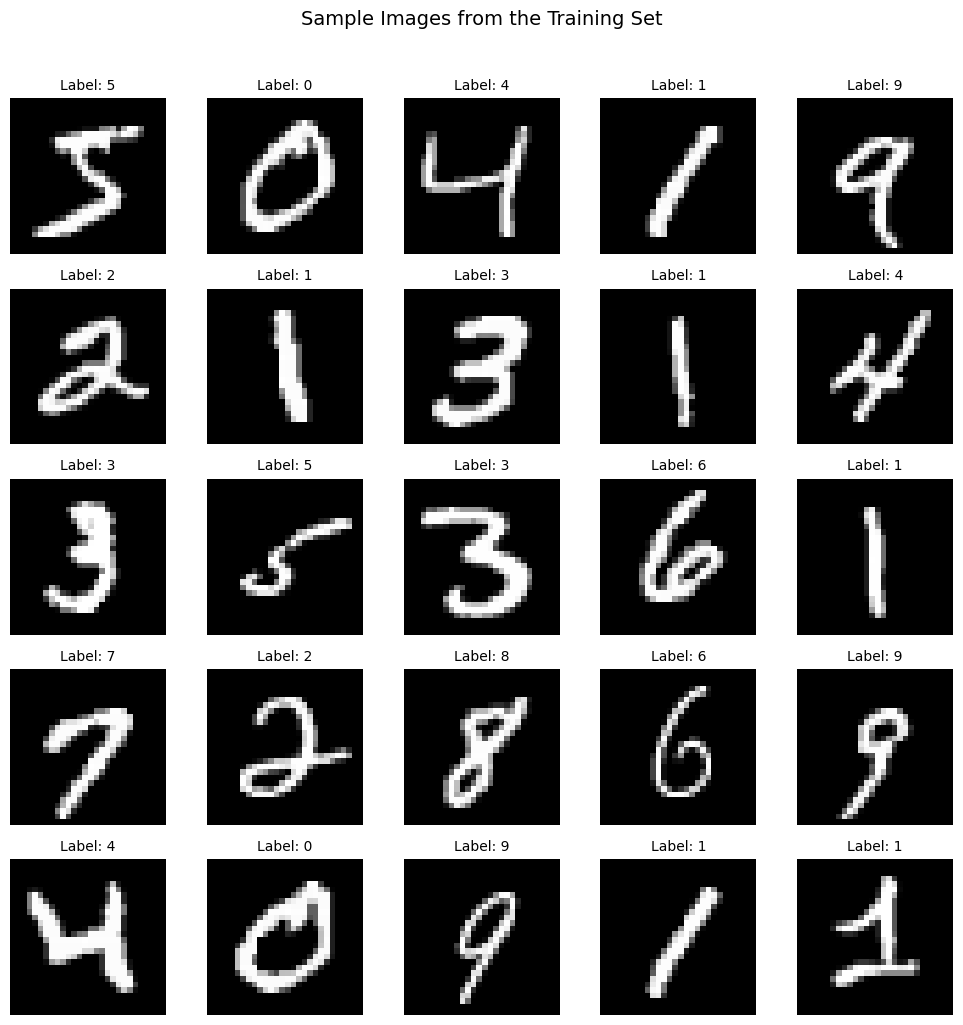

In [4]:
# Show 25 sample images from the training set
plt.figure(figsize=(10, 10))

for i in range(25):
    plt.subplot(5, 5, i + 1)       # Create a 5x5 grid of subplots
    plt.imshow(x_train[i], cmap='gray')  # Show image in grayscale
    plt.title(f"Label: {y_train[i]}", fontsize=10)
    plt.axis('off')                 # Hide the x/y axis ticks

plt.suptitle("Sample Images from the Training Set", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Label (correct answer): 5
Image shape: (28, 28)  (28 rows × 28 columns of pixels)
Pixel value range: min=0, max=255

Raw pixel grid (partial):
[[  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  30  36]
 [  0   0   0   0   0   0   0  49 238 253]
 [  0   0   0   0   0   0   0  18 219 253]
 [  0   0   0   0   0   0   0   0  80 156]]


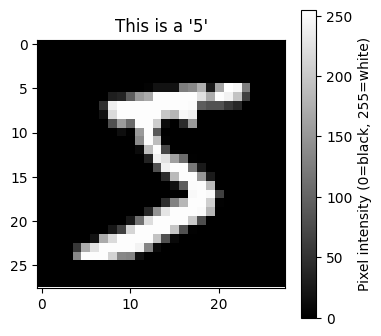

In [5]:
# Zoom in on one image
# Let's look at the very first training image in detail
index = 0
print(f"Label (correct answer): {y_train[index]}")
print(f"Image shape: {x_train[index].shape}  (28 rows × 28 columns of pixels)")
print(f"Pixel value range: min={x_train[index].min()}, max={x_train[index].max()}")
print("\nRaw pixel grid (partial):")
print(x_train[index][:10, :10])   # Show only top-left 10x10 corner

plt.figure(figsize=(4, 4))
plt.imshow(x_train[index], cmap='gray')
plt.title(f"This is a '{y_train[index]}'")
plt.colorbar(label='Pixel intensity (0=black, 255=white)')
plt.show()

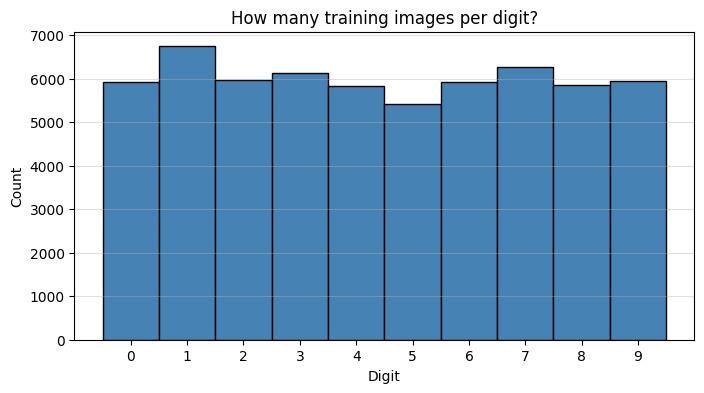

Count per digit in training set:
  Digit 0: 5923 images
  Digit 1: 6742 images
  Digit 2: 5958 images
  Digit 3: 6131 images
  Digit 4: 5842 images
  Digit 5: 5421 images
  Digit 6: 5918 images
  Digit 7: 6265 images
  Digit 8: 5851 images
  Digit 9: 5949 images


In [6]:
# How many images of each digit do we have?
plt.figure(figsize=(8, 4))
plt.hist(y_train, bins=range(11), edgecolor='black', color='steelblue', align='left')
plt.xticks(range(10))
plt.xlabel("Digit")
plt.ylabel("Count")
plt.title("How many training images per digit?")
plt.grid(axis='y', alpha=0.4)
plt.show()

print("Count per digit in training set:")
for digit in range(10):
    count = np.sum(y_train == digit)
    print(f"  Digit {digit}: {count} images")

## Step 4: Preprocess (Prepare) the Data

Neural networks work best with small numbers. Right now pixel values are **0 to 255**.

We'll do two things:
1. **Normalize** pixel values to the range **0.0 – 1.0** (just divide by 255)
2. **Flatten** each 28×28 image into a single row of 784 numbers

Think of it like unrolling a photograph into one long strip.

In [7]:
# Normalize pixel values from [0, 255] → [0.0, 1.0]
x_train_norm = x_train / 255.0
x_test_norm  = x_test  / 255.0

print(f"Before normalization: min={x_train.min()}, max={x_train.max()}")
print(f"After  normalization: min={x_train_norm.min():.1f}, max={x_train_norm.max():.1f}")

# Flatten 28x28 images → 784-element vectors
# reshape(-1, 784) means: keep all images (-1), flatten each to 784 numbers
x_train_flat = x_train_norm.reshape(-1, 784)
x_test_flat  = x_test_norm.reshape(-1, 784)

print(f"\nShape before flattening: {x_train_norm.shape}")
print(f"Shape after  flattening: {x_train_flat.shape}")
print("\n Data is ready!")

Before normalization: min=0, max=255
After  normalization: min=0.0, max=1.0

Shape before flattening: (60000, 28, 28)
Shape after  flattening: (60000, 784)

 Data is ready!


## Step 5: Build a Neural Network Model

We'll build a simple **3-layer neural network**:

```
Input (784 pixels)
       ↓
 Dense Layer (128 neurons, ReLU activation)
       ↓
 Dense Layer (64 neurons, ReLU activation)
       ↓
 Output Layer (10 neurons, Softmax activation)
       ↓
 Prediction: probabilities for digits 0–9
```

**Key terms:**
- **Dense layer** — every neuron connects to every neuron in the next layer
- **ReLU** — an activation function that adds non-linearity (helps the network learn complex patterns)
- **Softmax** — converts the final numbers into *probabilities* that add up to 1.0

In [8]:
# Build the model
model = tf.keras.Sequential([
    # Layer 1: Input layer — accepts 784 numbers
    tf.keras.layers.Input(shape=(784,)),

    # Layer 2: First hidden layer — 128 neurons
    tf.keras.layers.Dense(128, activation='relu'),

    # Layer 3: Second hidden layer — 64 neurons
    tf.keras.layers.Dense(64, activation='relu'),

    # Layer 4: Output layer — 10 neurons (one per digit 0-9)
    tf.keras.layers.Dense(10, activation='softmax')
])

# Compile the model
# optimizer  → how the model updates its weights (Adam is a popular choice)
# loss       → how we measure mistakes (sparse_categorical means labels are integers 0-9)
# metrics    → what we want to track during training (accuracy)
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Print a summary of the model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## Step 6: Train the Model

**Training** means showing the model thousands of images and letting it adjust its internal weights to get better at guessing.

- **Epochs** = how many times the model sees the entire training dataset
- **Batch size** = how many images are processed at a time before updating weights
- **Validation split** = we hold back 10% of training data to monitor performance on unseen data

In [9]:
# Train the model
print("Training started...\n")

history = model.fit(
    x_train_flat,   # Training images
    y_train,        # Correct labels
    epochs=10,      # Go through ALL training images 10 times
    batch_size=64,  # Process 64 images at a time
    validation_split=0.1,  # Use 10% of data for validation
    verbose=1       # Print progress after each epoch
)

print("\n Training complete!")

Training started...

Epoch 1/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - accuracy: 0.9153 - loss: 0.2952 - val_accuracy: 0.9632 - val_loss: 0.1257
Epoch 2/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9663 - loss: 0.1142 - val_accuracy: 0.9707 - val_loss: 0.1035
Epoch 3/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.9766 - loss: 0.0759 - val_accuracy: 0.9780 - val_loss: 0.0816
Epoch 4/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9814 - loss: 0.0596 - val_accuracy: 0.9787 - val_loss: 0.0757
Epoch 5/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9854 - loss: 0.0455 - val_accuracy: 0.9785 - val_loss: 0.0779
Epoch 6/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9885 - loss: 0.0374 - val_accuracy: 0.9778 - val_loss: 0.0813
Epoch 7/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9903 - loss: 0.0289 - val_accuracy: 0.9787 - val_loss: 0.0813
Epoch 8/10
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9927 - loss: 0.

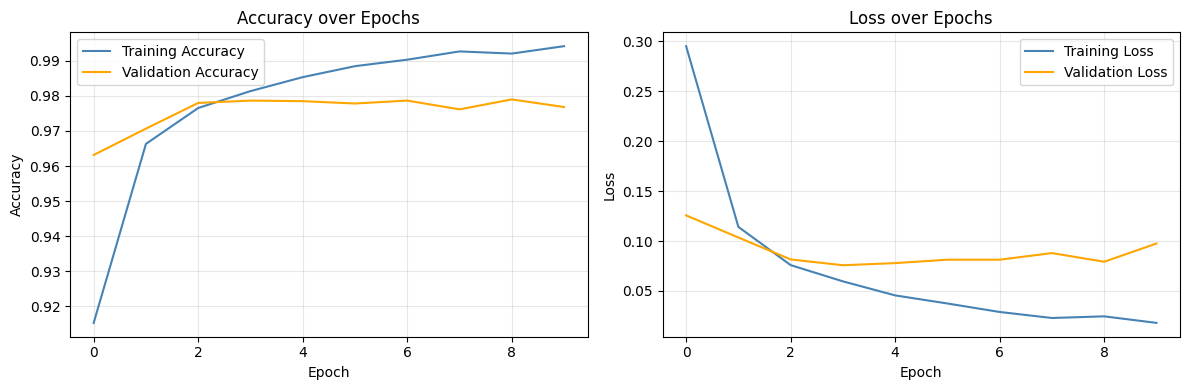

As epochs increase, accuracy goes UP and loss goes DOWN — that's good!


In [10]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Accuracy plot
axes[0].plot(history.history['accuracy'],     label='Training Accuracy',   color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy over Epochs')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Loss plot
axes[1].plot(history.history['loss'],     label='Training Loss',   color='steelblue')
axes[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].set_title('Loss over Epochs')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("As epochs increase, accuracy goes UP and loss goes DOWN — that's good!")

## Step 7: Evaluate the Model

Now we test the model on **10,000 images it has never seen** during training.

In [11]:
# Evaluate on the test set
test_loss, test_accuracy = model.evaluate(x_test_flat, y_test, verbose=0)

print(f"Test Loss    : {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"\n Our model correctly identifies {test_accuracy * 100:.1f}% of handwritten digits!")

Test Loss    : 0.0925
Test Accuracy: 97.62%

 Our model correctly identifies 97.6% of handwritten digits!


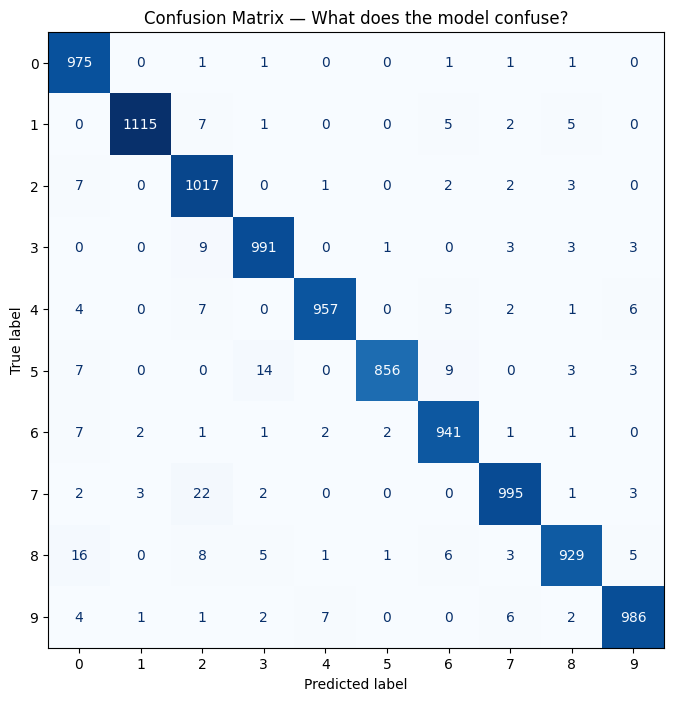

The diagonal cells (top-left to bottom-right) are CORRECT predictions.
Off-diagonal cells show mistakes — e.g., predicting '4' when the true label was '9'.


In [12]:
# Confusion Matrix
# A confusion matrix shows which digits get confused with each other
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get model predictions for all test images
y_pred_probs = model.predict(x_test_flat, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)  # Pick the digit with highest probability

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=range(10))

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — What does the model confuse?")
plt.show()

print("The diagonal cells (top-left to bottom-right) are CORRECT predictions.")
print("Off-diagonal cells show mistakes — e.g., predicting '4' when the true label was '9'.")

## Step 8: Make Predictions on Individual Images

Let's pick random test images and see what the model predicts!

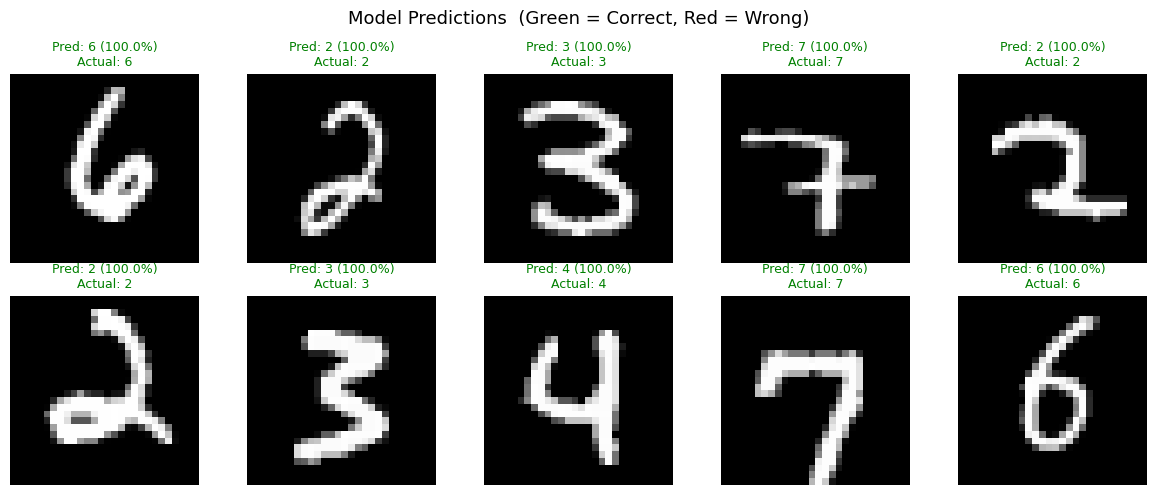

In [13]:
# Predict on 10 random test images
np.random.seed(42)
random_indices = np.random.choice(len(x_test), 10, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, idx in enumerate(random_indices):
    # Get model output: an array of 10 probabilities (one per digit)
    probs     = model.predict(x_test_flat[idx:idx+1], verbose=0)[0]
    predicted = np.argmax(probs)    # Digit with highest probability
    actual    = y_test[idx]         # True label
    confidence = probs[predicted] * 100

    axes[i].imshow(x_test[idx], cmap='gray')
    color = 'green' if predicted == actual else 'red'
    axes[i].set_title(
        f"Pred: {predicted} ({confidence:.1f}%)\nActual: {actual}",
        color=color, fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Model Predictions  (Green = Correct, Red = Wrong)", fontsize=13)
plt.tight_layout()
plt.show()

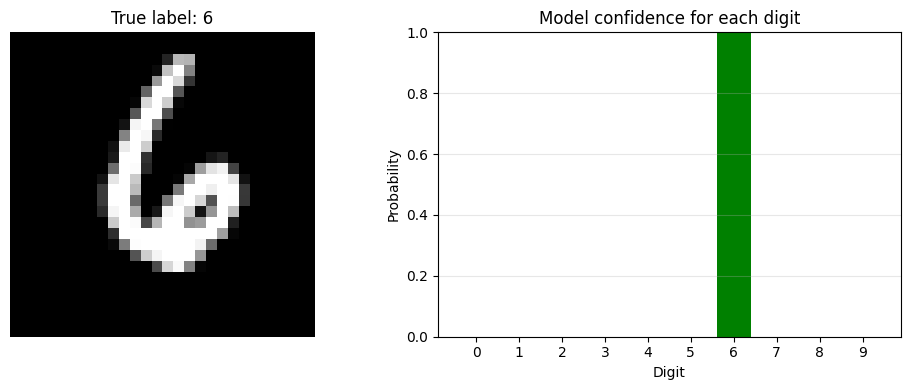

The model is 100.0% confident this is a '6'


In [14]:
# Deep-dive: probability breakdown for ONE image
idx   = random_indices[0]
probs = model.predict(x_test_flat[idx:idx+1], verbose=0)[0]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

# Show the image
ax1.imshow(x_test[idx], cmap='gray')
ax1.set_title(f"True label: {y_test[idx]}")
ax1.axis('off')

# Show probability for each digit
colors = ['green' if i == np.argmax(probs) else 'steelblue' for i in range(10)]
ax2.bar(range(10), probs, color=colors)
ax2.set_xticks(range(10))
ax2.set_xlabel("Digit")
ax2.set_ylabel("Probability")
ax2.set_title("Model confidence for each digit")
ax2.set_ylim(0, 1)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"The model is {probs[np.argmax(probs)]*100:.1f}% confident this is a '{np.argmax(probs)}'")

## Important: Look at the Mistakes

What does the model get *wrong*? Let's find some mistakes.

Total mistakes on 10,000 test images: 238
Accuracy = 97.6%


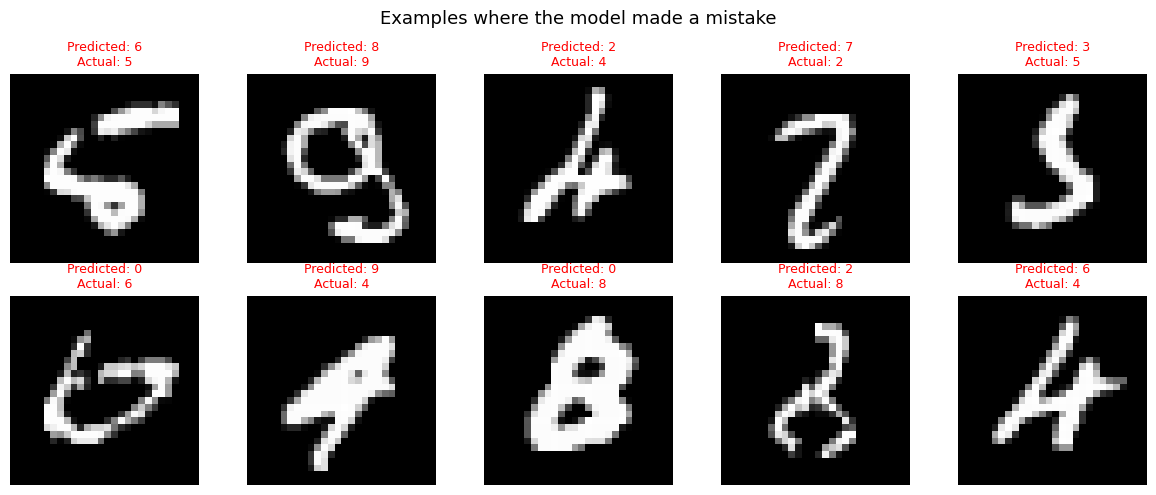


Notice: even humans might find some of these hard to read!


In [15]:
# Find and display wrong predictions
wrong_indices = np.where(y_pred != y_test)[0]   # All indices where model was wrong

print(f"Total mistakes on 10,000 test images: {len(wrong_indices)}")
print(f"Accuracy = {(10000 - len(wrong_indices)) / 100:.1f}%")

# Show the first 10 mistakes
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for i, idx in enumerate(wrong_indices[:10]):
    axes[i].imshow(x_test[idx], cmap='gray')
    axes[i].set_title(
        f"Predicted: {y_pred[idx]}\nActual: {y_test[idx]}",
        color='red', fontsize=9
    )
    axes[i].axis('off')

plt.suptitle("Examples where the model made a mistake", fontsize=13)
plt.tight_layout()
plt.show()

print("\n Notice: even humans might find some of these hard to read!")

## Summary: What You Learned

| Step | What we did |
|------|-------------|
| 1 | Installed and imported Python libraries |
| 2 | Loaded the MNIST dataset (60k train + 10k test) |
| 3 | Visualized sample images and label distribution |
| 4 | Normalized pixels to [0,1] and flattened images |
| 5 | Built a 3-layer neural network |
| 6 | Trained the model for 10 epochs |
| 7 | Evaluated accuracy (~97%) and confusion matrix |
| 8 | Made predictions and visualized confidence |

---

## Challenge: Can You Do Better?

Try changing these things and see if accuracy improves:

```python
# 1. Add more neurons
tf.keras.layers.Dense(256, activation='relu'),

# 2. Add Dropout to prevent overfitting
tf.keras.layers.Dropout(0.2),

# 3. Train for more epochs
epochs=20

# 4. Try a different optimizer
optimizer='sgd'
```

For an even bigger jump, try a **Convolutional Neural Network (CNN)**  it's designed specifically for images and can reach **99%+ accuracy** on MNIST!

---

>  **Great work!** You just built and trained your first neural network from scratch.